In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
import sys

In [2]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
for pkg in ['pandas', 'numpy', 'matplotlib']:
    mod = __import__(pkg)
    print(f"{pkg}: {mod.__version__}")
print(f"Python: {sys.version.split()[0]}")

pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
Python: 3.13.9


In [4]:
RAW_PATH = '../data/raw/L4_Tidy_2024_ALL_LA.csv'
OUTPUT_DIR = '../outputs/phase1'

In [5]:
#Sentinel strings that are used in the dataset
SENTINELS = {
    'c': 'suppressed - small number, confidentiality',
    'z': 'not applicable',
    'x': 'not available',
    'low': 'positive value, less than 0.5%',
    '0': 'true zero'
}

In [6]:
#Feature columns that are numeric
NUM_COLS = [
    'all_cohort', 'all_progressed', 'all_degree', 'all_top3rd', 'all_appren', 'all_htech', 'acag_cohort', 'acag_progressed',
    'tlev_cohort', 'tlev_progressed', 'otl3_cohort', 'otl3_progressed'
]

In [7]:
#There were cohort break years according to documentation the composition criteria changed for these years
COHORT_BREAK_YEARS = [202021, 202122]

In [8]:
df = pd.read_csv(RAW_PATH, low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape: 44,342 rows x 30 columns


In [9]:
#Column Names
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Column Names:
   1. time_period
   2. time_identifier
   3. geographic_level
   4. country_code
   5. country_name
   6. region_code
   7. region_name
   8. old_la_code
   9. new_la_code
  10. la_name
  11. pcon_code
  12. pcon_name
  13. level_methodology
  14. institution_group
  15. institution_type
  16. breakdown_topic
  17. breakdown
  18. data_type
  19. all_cohort
  20. all_progressed
  21. all_degree
  22. all_top3rd
  23. all_appren
  24. all_htech
  25. acag_cohort
  26. acag_progressed
  27. tlev_cohort
  28. tlev_progressed
  29. otl3_cohort
  30. otl3_progressed


In [10]:
df.head(3).T

,0,1,2
time_period,202122,202122,202122
time_identifier,Academic year,Academic year,Academic year
geographic_level,Local authority,Local authority,Local authority
country_code,E92000001,E92000001,E92000001
country_name,England,England,England
region_code,E12000001,E12000001,E12000001
region_name,North East,North East,North East
old_la_code,390.00,390.00,390.00
new_la_code,E08000037,E08000037,E08000037
la_name,Gateshead,Gateshead,Gateshead


In [11]:
#Determining the types of columns

print(df.dtypes)

time_period            int64
time_identifier       object
geographic_level      object
country_code          object
country_name          object
region_code           object
region_name           object
old_la_code          float64
new_la_code           object
la_name               object
pcon_code             object
pcon_name             object
level_methodology     object
institution_group     object
institution_type      object
breakdown_topic       object
breakdown             object
data_type             object
all_cohort            object
all_progressed        object
all_degree            object
all_top3rd            object
all_appren            object
all_htech             object
acag_cohort           object
acag_progressed       object
tlev_cohort           object
tlev_progressed       object
otl3_cohort           object
otl3_progressed       object
dtype: object


In [12]:
'''Before we do any transformation it is important that we know exactly how many sentinel strings exist in each numeric column.
This will drive our imputation strategy later on '''

sentinel_keys = list(SENTINELS.keys())
sentinel_keys

['c', 'z', 'x', 'low', '0']

In [13]:
rows = []
for col in NUM_COLS:
    col_str = df[col].astype(str).str.strip()
    total = len(col_str)
    row = {'column': col}
    for s in sentinel_keys:
        count = (col_str == s).sum()
        row[s] = count
    #Anything that is not a digit, sentinel or decimal point
    is_numeric = pd.to_numeric(df[col], errors='coerce').notna()
    row['numeric'] = is_numeric.sum()
    row['total'] = total
    row['pct_clean'] = f"{is_numeric.mean()*100:.1f}%"
    rows.append(row)

audit = pd.DataFrame(rows).set_index('column')
print("Sentinel counts per numeric column:")
print()
print(audit.to_string())

Sentinel counts per numeric column:

                   c    z  x  low      0  numeric  total pct_clean
column                                                            
all_cohort         0    0  0    2    510    44340  44342    100.0%
all_progressed    24  255  0    1    313    44062  44342     99.4%
all_degree        16  255  0    1    343    44070  44342     99.4%
all_top3rd        24  255  0   10   1242    44053  44342     99.3%
all_appren        84  255  0  362   4289    43641  44342     98.4%
all_htech        100  255  0   94   3457    43893  44342     99.0%
acag_cohort       24    0  0    8    914    44310  44342     99.9%
acag_progressed   48  255  0    2    760    44037  44342     99.3%
tlev_cohort      152    0  0   66   8318    44124  44342     99.5%
tlev_progressed  304  255  0   92   9136    43691  44342     98.5%
otl3_cohort      156    0  0   66   8904    44120  44342     99.5%
otl3_progressed  316  255  0  104  10389    43667  44342     98.5%


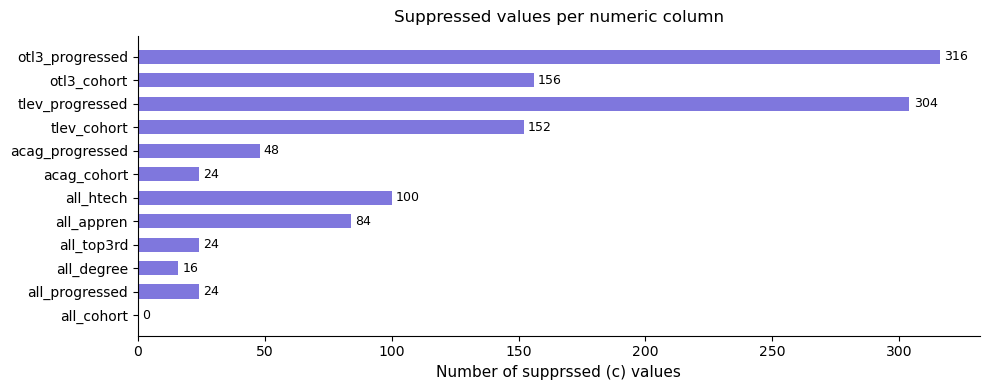

In [14]:
#Lets visualise suppression ('c') by column
fig, ax = plt.subplots(figsize=(10,4))
colors = ['#7F77DD' if v > 0 else '#D3D1C7' for v in audit['c']]
bars = ax.barh(audit.index, audit['c'], color=colors, height=0.6)
ax.set_xlabel('Number of supprssed (c) values', fontsize=11)
ax.set_title('Suppressed values per numeric column', fontsize=12, pad=10)
ax.bar_label(bars, padding=3, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentinel_suppressed_counts.png', dpi=150, bbox_inches='tight')
plt.show()

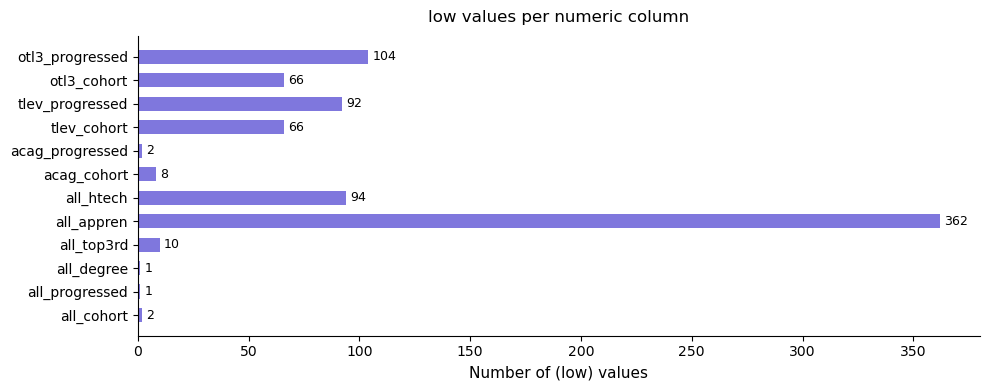

In [15]:
#Lets visualise ('low') by column
fig, ax = plt.subplots(figsize=(10,4))
colors = ['#7F77DD' if v > 0 else '#D3D1C7' for v in audit['low']]
bars = ax.barh(audit.index, audit['low'], color=colors, height=0.6)
ax.set_xlabel('Number of (low) values', fontsize=11)
ax.set_title('low values per numeric column', fontsize=12, pad=10)
ax.bar_label(bars, padding=3, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentinel_low_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("KEY FINDINGS: ")
print(f"'z'(not applicable) dominates progression columns - these rows have qualification types with no applicable students.")
print(f"'c' suppression is heaviest in tlev/otl3 columns which is basically tech level and other L3. These are the smallest qualification cohorts.")
print(f"'low' appears in all_appren (362 times) which means a significant share of apprenticeship rates will be coerced to a mid-point value in further analysis")

KEY FINDINGS: 
'z'(not applicable) dominates progression columns - these rows have qualification types with no applicable students.
'c' suppression is heaviest in tlev/otl3 columns which is basically tech level and other L3. These are the smallest qualification cohorts.
'low' appears in all_appren (362 times) which means a significant share of apprenticeship rates will be coerced to a mid-point value in further analysis


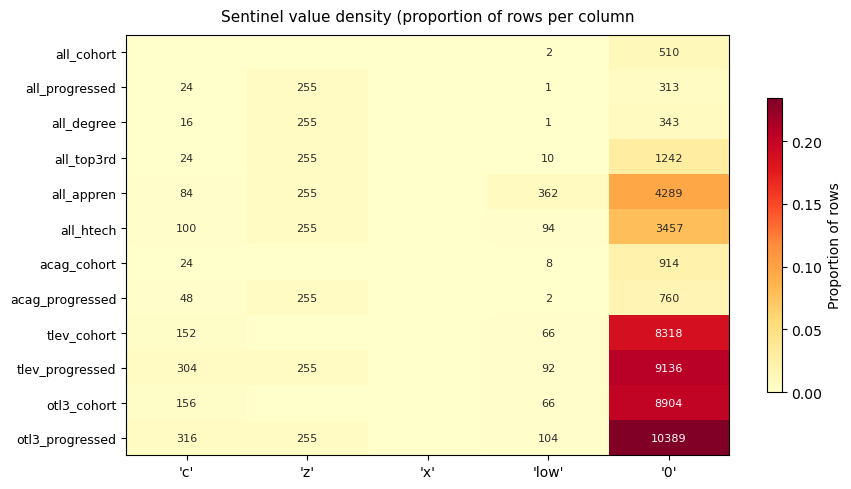

In [17]:
fig, ax = plt.subplots(figsize=(9,5))

heat_data = audit[sentinel_keys].values

heat_norm = heat_data / audit['total'].values.reshape(-1,1)

im = ax.imshow(heat_norm, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(len(sentinel_keys)))
ax.set_xticklabels([f"'{s}'" for s in sentinel_keys], fontsize=10)
ax.set_yticks(range(len(NUM_COLS)))
ax.set_yticklabels(NUM_COLS, fontsize=9)
ax.set_title('Sentinel value density (proportion of rows per column', fontsize=11, pad=10)

for i in range(len(NUM_COLS)):
    for j in range(len(sentinel_keys)):
        val = heat_data[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8,
                   color = 'white' if heat_norm[i,j] > 0.15 else '#2C2C2A')


plt.colorbar(im, ax=ax, label='Proportion of rows', shrink=0.7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sentinel_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

From the above three things stand out:

First, tlev and otl3 columns in the bottom right corner are dark red in the '0' column. This shows that majority of local authorities have zero students in tech level or other Level 3 pathways. This means that these qualification types are rare and unevenly distributed. Our model will be handling this carefully.

Second, we can 'z' being consistent at 255 in the progression columns. These are probably the same Local Authorities every time whihc a particular instituion type had no students at all that year.

Third, there are 362 'low' calues in all_appren. This is more than any other column. Apprenticiship rates are tiny almost everywhere which means this feature will have very low variance and may not be useful for the model.

# The Geographic Hierarchy

In [18]:
#First we will observe time_period rows counts with geographic level

geo_time = df.groupby(['geographic_level', 'time_period']).size().unstack(fill_value=0)
print("Row counts by geographic level x year:")
print(geo_time.to_string())

Row counts by geographic level x year:
time_period                 201516  201617  201718  201819  201920  202021  202122
geographic_level                                                                  
Local authority               3262    3244    3212    3198    8172    8190    5002
Parliamentary constituency    1066    1066    1062    1062    1062    1062    1064
Regional                       242     242     242     242     638     638     374


There is a sharp jump from 2019/20 onwards in the Local Authority row. The reason is that the breakdown taxonomy expanded hence more demographic groups were reported from 2019/20. This can't be looked as a data error. <br>
The Parliamentary constituency is stable which can be useful for validation.

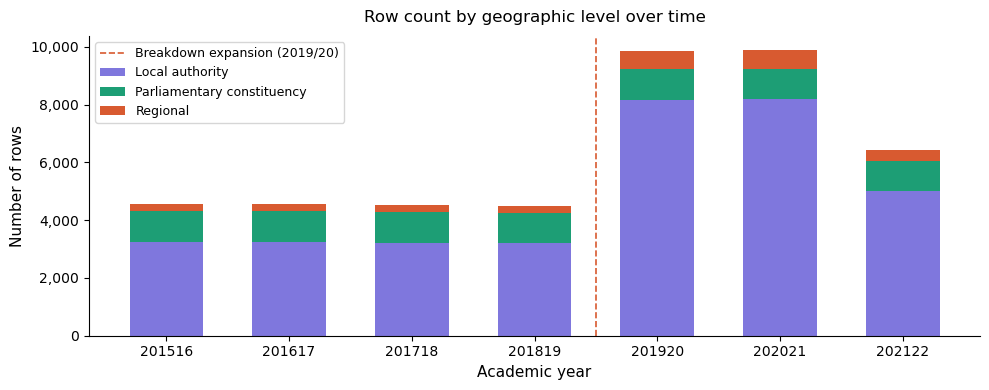

In [19]:
#Visualising the above

fig, ax = plt.subplots(figsize=(10, 4))

year_labels = [str(y) for y in geo_time.columns]
colors_geo = {'Local authority': '#7F77DD',
             'Parliamentary constituency': '#1D9E75',
             'Regional': '#D85A30'}

bottoms = np.zeros(len(geo_time.columns))
for geo_level in geo_time.index:
    vals = geo_time.loc[geo_level].values
    ax.bar(year_labels, vals, bottom=bottoms, label=geo_level,
          color=colors_geo.get(geo_level, '#888780'), width = 0.6)
    bottoms += vals

ax.axvline(x=3.5, color='#D85A30', linestyle='--', linewidth=1.2,
          label='Breakdown expansion (2019/20)')
ax.set_xlabel('Academic year', fontsize=11)
ax.set_ylabel('Number of rows', fontsize=11)
ax.set_title('Row count by geographic level over time', fontsize=12, pad=10)
ax.legend(fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/geo_level_row_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
#We will count level_methodogy now as this is where our data leakage risk lies

print("level_methodology value counts:")
print(df['level_methodology'].value_counts())


level_methodology value counts:
level_methodology
Local education authority area    36898
16-18 Provider location            7444
Name: count, dtype: int64


In [21]:
#Checking whether the same LA appears under both methodologies in the same year

la_data = df[df['geographic_level'] == 'Local authority'].copy()
overlap = la_data.groupby(['la_name', 'time_period'])['level_methodology'].nunique()
dual_count = (overlap > 1).sum()

print(f"LA appearing in both methodologies for same year: {dual_count:,}")

LA appearing in both methodologies for same year: 0


Even thought LA appearing both methodologies for the same year is 0 but there is a risk that these dual-methodology might be representing the same underlying population attributed to different geographies. For example where student is living and where their training provider is. Hence, mixing them will inflate the training set with near-duplicates. <br>
Hence, we should filter it through 'Local education authority area' in Phase 2 of our model.

In [22]:
#Checking how many unique LAs per year using LEA

lea = la_data[la_data['level_methodology'] == 'Local education authority area']
la_counts = lea.groupby('time_period')['la_name'].nunique()

print("Unique LAs per year (LEA methodology, all breakdowns):")
print(la_counts.to_string())

Unique LAs per year (LEA methodology, all breakdowns):
time_period
201516    151
201617    151
201718    151
201819    150
201920    150
202021    151
202122    151


The above shows that the panel is balanced (151 LAs across all years). The reason 2018/19 and 2019/20 shows 150 could be because of change in boundary during that year.

# Dual data_type encoding

The dataset stores every observation twice: once as raw counts (Number of pupils) and once as a percentage (Percentage). When feature engineering, we must filter to counts only.

In [23]:
print("data_type value counts:")
print(df['data_type'].value_counts())

data_type value counts:
data_type
Number of pupils    22171
Percentage          22171
Name: count, dtype: int64


In [24]:
print(f"Total rows: {len(df):,}")
print(f"Count rows: {(df['data_type']=='Number of pupils').sum():,}")
print(f"Percentage rows: {(df['data_type']=='Percentage').sum():,}")

Total rows: 44,342
Count rows: 22,171
Percentage rows: 22,171


In [25]:
#To confirm they are exact mirrors of each i.e. belong to same LA and same year.

counts_index = df[df['data_type']=='Number of pupils'].set_index(
    ['la_name', 'time_period', 'breakdown', 'institution_group', 'level_methodology']
).index

pct_index = df[df['data_type']=='Percentage'].set_index(
    ['la_name', 'time_period', 'breakdown', 'institution_group', 'level_methodology']
).index

print(f"Count rows unique index size: {len(counts_index.unique()):,}")
print(f"Percentage rows unique index size: {len(pct_index.unique()):,}")

Count rows unique index size: 17,266
Percentage rows unique index size: 17,266


# Breakdown taxonomy audit

The breakdown column encodes the demographic group for each row. Understanding its full taxonomy determines how the target variable will be defined and whether the dmeographic group should be a feature or a stratification variable

In [26]:
la_counts_only = df[
(df['geographic_level'] == 'Local authority') &
(df['level_methodology'] == 'Local education authority area') &
(df['data_type'] == 'Number of pupils')
]

taxonomy = (
    la_counts_only.groupby(['breakdown_topic', 'breakdown']).size().reset_index(name='row_count').sort_values(['breakdown_topic', 'row_count'], ascending=[True, False])
)

for topic, grp in taxonomy.groupby('breakdown_topic'):
    print(f"{topic}")
    for _, row in grp.iterrows():
        print(f" |-- {row['breakdown']:<35s}  ({row['row_count']:,} rows)")

Disadvantage status
 |-- Disadvantaged                        (1,048 rows)
 |-- Not disadvantaged                    (1,048 rows)
Ethnicity Major
 |-- White                                (1,002 rows)
 |-- Mixed Dual background                (997 rows)
 |-- Asian or Asian British               (990 rows)
 |-- Unclassified                         (964 rows)
 |-- Black or Black British               (961 rows)
 |-- Any other ethnic group               (959 rows)
LLDD Provision
 |-- No identified LLDD                   (916 rows)
 |-- Identified LLDD                      (915 rows)
SEN Provision
 |-- No identified SEN                    (1,043 rows)
 |-- Identified SEN                       (1,036 rows)
Sex
 |-- Female                               (1,048 rows)
 |-- Male                                 (1,048 rows)
Total
 |-- Total                                (3,165 rows)


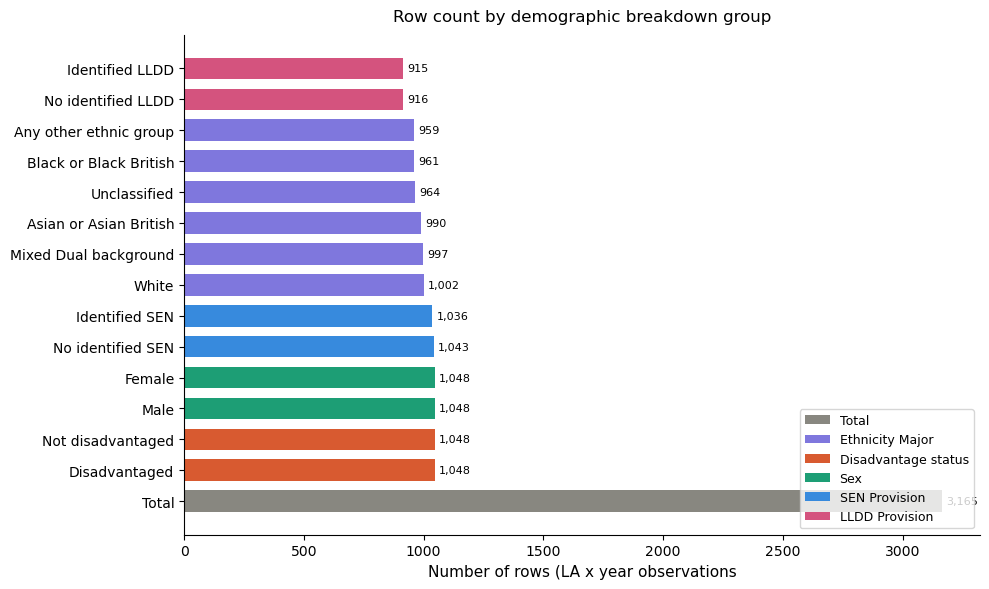

In [27]:
#Visualise the distribution

breakdown_counts = la_counts_only['breakdown'].value_counts()

fig, ax = plt.subplots(figsize=(10,6))

topic_color = {
    'Total': '#888780',
    'Ethnicity Major': '#7f77DD',
    'Disadvantage status': '#D85A30',
    'Sex': '#1D9E75',
    'SEN Provision': '#378ADD',
    'LLDD Provision': '#D4537E'
}

#Assign each breakdown to its topic for colour mapping
breakdown_to_topic = la_counts_only.drop_duplicates('breakdown').set_index('breakdown')['breakdown_topic']
colors = [topic_color.get(breakdown_to_topic.get(b, 'Total'), '#888780') for b in breakdown_counts.index]

bars = ax.barh(breakdown_counts.index, breakdown_counts.values, color=colors, height=0.7)
ax.bar_label(bars, padding=3, fontsize=8,
            labels=[f'{v:,}' for v in breakdown_counts.values])

ax.set_xlabel('Number of rows (LA x year observations', fontsize=11)
ax.set_title('Row count by demographic breakdown group', fontsize=12, pad=10)
ax.spines[['top', 'right']].set_visible(False)

#Make legends
from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=c, label=t) for t, c in topic_color.items()]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/breakdown_taxonomy.png', dpi=150, bbox_inches='tight')
plt.show()

# Institution Group audit

In [28]:
print("institution_group value counts (LA level, LEA, count rows):")
print(la_counts_only['institution_group'].value_counts())

institution_group value counts (LA level, LEA, count rows):
institution_group
State-funded mainstream schools & colleges    7918
State-funded mainstream schools               4839
State-funded mainstream colleges              4383
Name: count, dtype: int64


As we can see there are three institution groups. The 'State-funded mainstream schools & colleges' is the aggregate. This basically encompasses the other two. Therefore we will use the aggregate group for modelling. 

In [29]:
#Checking whether each LA x year x breakdown appears once per institution_group

per_combo = la_counts_only.groupby(
    ['la_name', 'time_period', 'breakdown']
)['institution_group'].nunique()

print(f"LA x year x breakdown combos with multiple institution groups: {(per_combo >1).sum():,}")

LA x year x breakdown combos with multiple institution groups: 2,831


# Cohort Size Profiling

Small cohorts produce unstable rates. Suppose a cohort with single student can move a rate by several percentage points. We need to understand the distribution and set a minimum cohort size for Phase 2

In [30]:
#The filter applied to modelling subset: LA, LEA, counts, aggregate institution

df_model_scope = df[
(df['geographic_level'] == 'Local authority') &
(df['level_methodology'] == 'Local education authority area') &
(df['data_type'] == 'Number of pupils') &
(df['institution_group'] == 'State-funded mainstream schools & colleges')
].copy()

print(f"Modelling scope: {len(df_model_scope):,} rows")

Modelling scope: 7,918 rows


In [31]:
#Convert all cohort to numeric
df_model_scope['all_cohort_num'] = pd.to_numeric(df_model_scope['all_cohort'], errors='coerce')

print("all_cohort distribution (modelling scope)")
print(df_model_scope['all_cohort_num'].describe(percentiles=[0.05,0.1,0.25,0.5,0.75,0.9,0.95]))

all_cohort distribution (modelling scope)
count    7,917.00
mean     1,099.62
std      1,412.25
min          0.00
5%          12.00
10%         27.00
25%        175.00
50%        685.00
75%      1,445.00
90%      2,545.40
95%      3,742.60
max     12,956.00
Name: all_cohort_num, dtype: float64


In [32]:
n_zero = (df_model_scope['all_cohort_num'] == 0).sum()
n_tiny = (df_model_scope['all_cohort_num'] <10).sum()
n_small = (df_model_scope['all_cohort_num'] <30).sum()
n_null = df_model_scope['all_cohort_num'].isna().sum()

In [33]:
print(f"Zero cohort rows: {n_zero:,}. These must be excluded")
print(f"Cohort <10 rows: {n_tiny:,}. These are extremely unstable rates")
print(f"Cohort <30 rows: {n_small:,}. This can be considered as minimum threshold")
print(f"NaN cohort rows: {n_null:,}")

Zero cohort rows: 7. These must be excluded
Cohort <10 rows: 328. These are extremely unstable rates
Cohort <30 rows: 834. This can be considered as minimum threshold
NaN cohort rows: 1


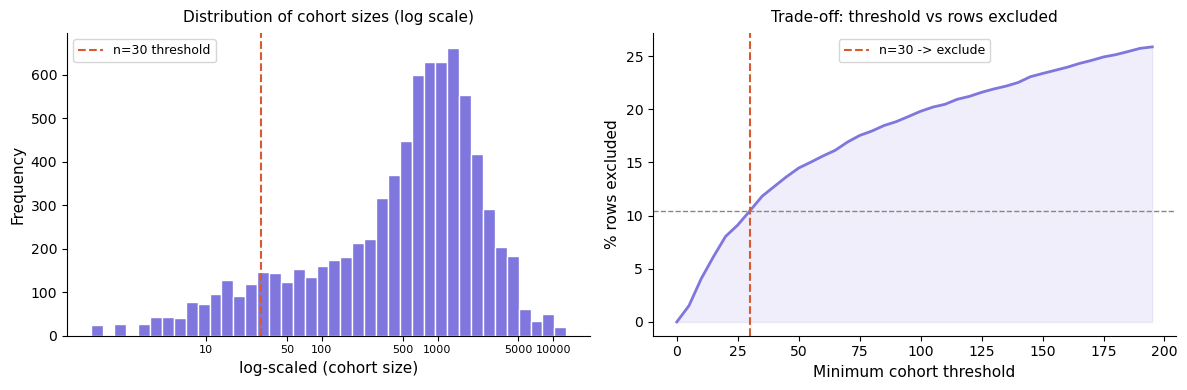

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

#1st Graph (left) will show full distribution log-scaled at x
cohort_vals = df_model_scope['all_cohort_num'].dropna()
cohort_vals = cohort_vals[cohort_vals>0]

axes[0].hist(np.log10(cohort_vals), bins=40, color='#7f77dd', edgecolor='white')
axes[0].set_xlabel('log-scaled (cohort size)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of cohort sizes (log scale)', fontsize=11, pad=8)
tick_vals = [10, 50, 100, 500, 1000, 5000, 10000]
axes[0].set_xticks(np.log10(tick_vals))
axes[0].set_xticklabels([str(v) for v in tick_vals], fontsize=8)
axes[0].axvline(np.log10(30), color='#D85a30', linestyle='--', label='n=30 threshold')
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

#2nd Graph (right) will show cumulative proportion below threshold
thresholds = np.arange(0, 200, 5)
pct_excluded = [(cohort_vals < t).mean()*100 for t in thresholds]

axes[1].plot(thresholds, pct_excluded, color='#7f77dd', linewidth=2)
axes[1].fill_between(thresholds, pct_excluded, alpha=0.12, color="#7f77dd")
axes[1].axvline(30, color='#d85a30', linestyle='--', label='n=30 -> exclude')
axes[1].axhline(pct_excluded[6], color='#888780', linestyle='--', linewidth=1)
axes[1].set_xlabel('Minimum cohort threshold', fontsize=11)
axes[1].set_ylabel('% rows excluded', fontsize=11)
axes[1].set_title('Trade-off: threshold vs rows excluded', fontsize=11, pad=8)
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cohort_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print(f"At threshold n=30: {pct_excluded[6]:.1f}% of rows excluded")
print("The minimum cohort size of 30 will be set in Phase 2")

At threshold n=30: 10.5% of rows excluded
The minimum cohort size of 30 will be set in Phase 2


# The Target Column: all_top3rd

In [41]:
#We will convert the target column to numeric in modelling scope also all_cohort

df_model_scope['top3rd_num'] = pd.to_numeric(df_model_scope['all_top3rd'], errors='coerce')
df_model_scope['cohort_num'] = pd.to_numeric(df_model_scope['all_cohort'], errors='coerce')

#Selecting rows that are valid in both to calculate rate
valid = df_model_scope[
df_model_scope['top3rd_num'].notna() &
df_model_scope['cohort_num'].notna() &
(df_model_scope['cohort_num'] > 0)
].copy()

valid['top3rd_rate'] = valid['top3rd_num'] / valid['cohort_num']

print(f"Valid rows for rate computation: {len(valid):,} of {len(df_model_scope):,}")

Valid rows for rate computation: 7,888 of 7,918


In [42]:
print("Top-third HE rate distribution (all breakdowns, valid rows):")
print(valid['top3rd_rate'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9]).to_string())

Top-third HE rate distribution (all breakdowns, valid rows):
count   7,888.00
mean        0.19
std         0.11
min         0.00
10%         0.08
25%         0.12
50%         0.18
75%         0.25
90%         0.33
max         1.00


In [44]:
#top3rd_rate by breakdown group (total only)
total_only = valid[valid['breakdown']=='Total'].copy()

print("Top-third HE rate (Total breakdown, all years, all LAs:")
print(total_only['top3rd_rate'].describe(percentiles=[0.1,0.25,0.5,0.75,0.9]).to_string())

Top-third HE rate (Total breakdown, all years, all LAs:
count   1,048.00
mean        0.19
std         0.08
min         0.00
10%         0.10
25%         0.13
50%         0.17
75%         0.23
90%         0.29
max         0.51


In [45]:
national_mean = total_only['top3rd_rate'].mean()
national_median = total_only['top3rd_rate'].median()

print(f"National mean (candidate threshold): {national_mean:.3f} ({national_mean*100:.1f}%)")
print(f"National median (candidate threshold): {national_median:.3f} ({national_median*100:.1f}%)")

National mean (candidate threshold): 0.188 (18.8%)
National median (candidate threshold): 0.174 (17.4%)


In [46]:
pct_above_mean = (total_only['top3rd_rate'] >= national_mean).mean()

print(f"Using national mean as threshold:")
print(f"{pct_above_mean*100:.1f}% of LA-year observations classified as 'on-track'")
print(f"{(1-pct_above_mean)*100:.1f}% classified as 'under-represented'")

Using national mean as threshold:
43.5% of LA-year observations classified as 'on-track'
56.5% classified as 'under-represented'


We will use national mean as binary threshold as the model is almost exactly balanced hence the best possible outcome for classifier

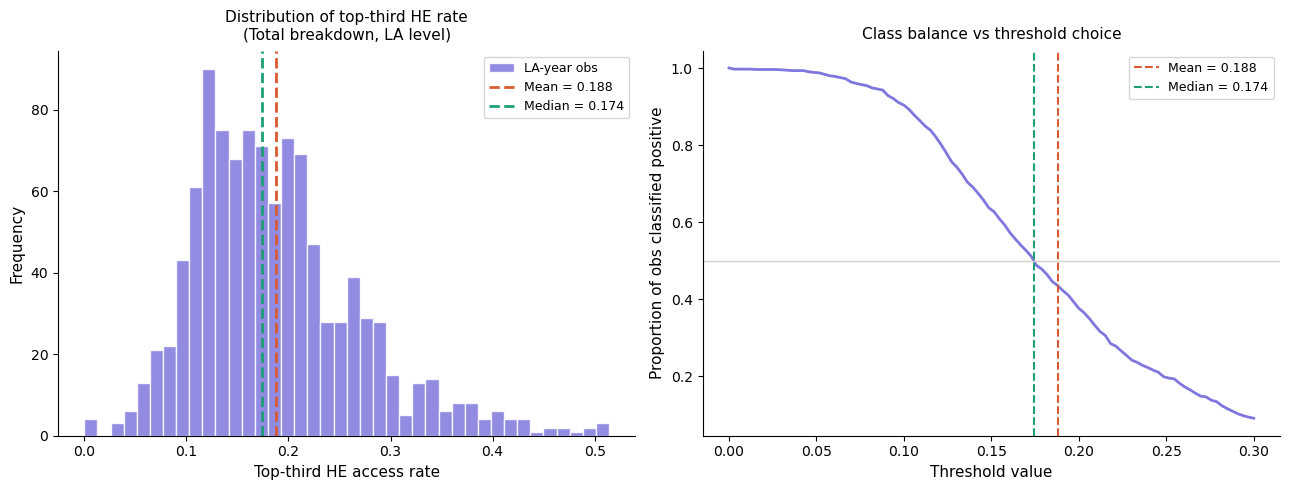

In [48]:
#Distribution with threshold lines
fig, axes = plt.subplots(1, 2, figsize=(13,5))

#1st Graph (left) is histogram
axes[0].hist(total_only['top3rd_rate'], bins=40, color='#7f77dd', edgecolor='white', alpha=0.85, label='LA-year obs')
axes[0].axvline(national_mean, color='#d85a30', lw=2, linestyle='--', label=f'Mean = {national_mean:.3f}')
axes[0].axvline(national_median, color='#1d9e75', lw=2, linestyle='--', label=f'Median = {national_median:.3f}')
axes[0].set_xlabel('Top-third HE access rate', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of top-third HE rate\n(Total breakdown, LA level)', fontsize=11, pad=8)
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

#2nd Graph (right) is class balance under each threshold candidate
thresholds_t = np.linspace(0, 0.3, 100)
pct_positive = [(total_only['top3rd_rate'] >=t).mean() for t in thresholds_t]

axes[1].plot(thresholds_t, pct_positive, color='#7f77dd', lw=2)
axes[1].axvline(national_mean, color='#d85a30', lw=1.5, linestyle='--', label=f'Mean = {national_mean:.3f}')
axes[1].axvline(national_median, color='#1d9e75', lw=1.5, linestyle='--', label=f'Median = {national_median:.3f}')
axes[1].axhline(0.5, color='#d3d1c7', lw=1, linestyle='-')
axes[1].set_xlabel('Threshold value', fontsize=11)
axes[1].set_ylabel('Proportion of obs classified positive', fontsize=11)
axes[1].set_title('Class balance vs threshold choice', fontsize=11, pad=8)
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

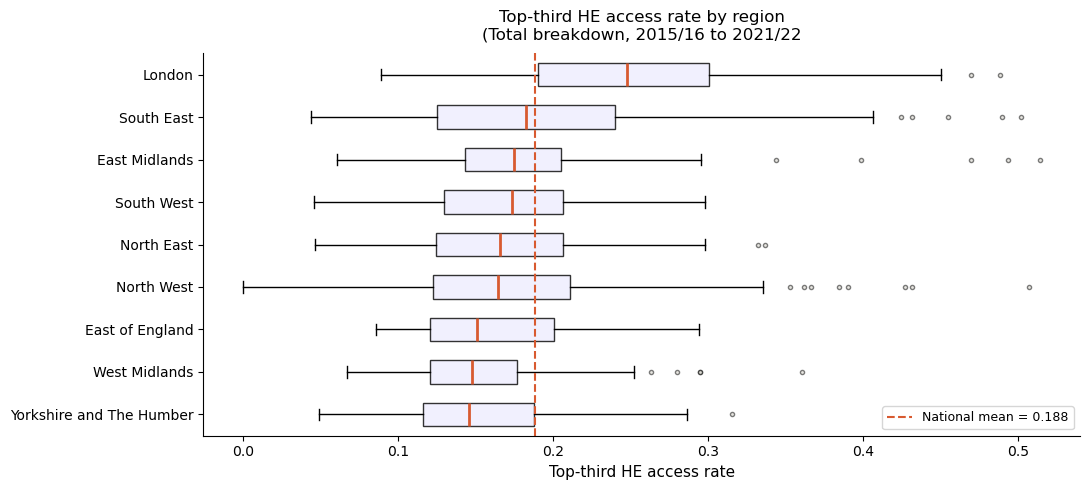

In [51]:
#top3rd_rate by region

region_order = (
    total_only.groupby('region_name')['top3rd_rate'].median().sort_values().index
)

fig, ax = plt.subplots(figsize=(11,5))

region_data = [total_only[total_only['region_name'] == r]['top3rd_rate'].dropna().values for r in region_order]

bp = ax.boxplot(region_data, vert=False, patch_artist=True, widths=0.55, showfliers=True,
               flierprops=dict(marker='o', markerfacecolor='#d3d1c7', markersize=3, alpha=0.5),
               medianprops=dict(color='#d85a30', linewidth=2))

for patch in bp['boxes']:
    patch.set_facecolor('#eeedfe')
    patch.set_alpha(0.8)

ax.set_yticks(range(1, len(region_order)+1))
ax.set_yticklabels(region_order, fontsize=10)
ax.axvline(national_mean, color='#d85a30', linestyle='--', lw=1.5, label=f'National mean = {national_mean:.3f}')
ax.set_xlabel('Top-third HE access rate', fontsize=11)
ax.set_title('Top-third HE access rate by region\n(Total breakdown, 2015/16 to 2021/22', fontsize=12, pad=10)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top3rd_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

Region alone is already strongly predictive of whether an LA falls below the threshold. When SHAP comes later on, region will almost certainly appear as one of the top features and this chart is the visual evidence of it. SHAP will quantify how much region vs qualification mix vs disadvantage each contribute to this pattern